In [2]:
!pip install ultralytics opencv-python pillow matplotlib

  Using cached ultralytics-8.4.38-py3-none-any.whl.metadata (39 kB)
  Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached polars-1.39.3-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.18-py3-none-any.whl.metadata (14 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached polars_runtime_32-1.39.3-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.5 kB)
Using cached ultralytics-8.4.38-py3-none-any.whl (1.2 MB)
Using cached opencv_python-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (72.9 MB)
Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
Using cached polars-1.39.3-py3-none-any.whl (823 kB)
Using cached polars_runtime_32-1.39.3-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (46.9 MB)
Using cached ultralytics_thop-2.0.18-py3-none-any.whl (28 kB)
  Attempting uninstall: nu

In [3]:
import cv2
import numpy as np
from ultralytics import SAM
from PIL import Image
import matplotlib.pyplot as plt

# Load SAM model once
model = SAM("sam2_s.pt")


(-0.5, 1548.5, 1042.5, -0.5)

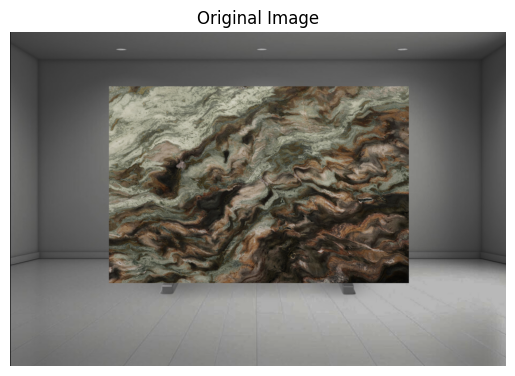

In [7]:
# 🔁 Replace with your local file path
image_path = "/home/Unthinkable/Downloads/stonex-development/image copy.png"

img = cv2.imread(image_path)

if img is None:
    raise ValueError(f"Could not read image at {image_path}")

# Show original
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

In [8]:
def crop_image(img):
    h, w, _ = img.shape
    center_y, center_x = h // 2, w // 2

    results = model.predict(
        img,
        points=[[center_x, center_y]],
        labels=[1],
        conf=0.4,
        verbose=False,
    )

    if results[0].masks is None:
        print("No mask found")
        return None

    masks = results[0].masks.data.cpu().numpy().astype(bool)

    candidate_indices = [
        i for i, m in enumerate(masks) if m[center_y, center_x]
    ]

    if not candidate_indices:
        print("No mask covers center")
        return None

    target_idx = candidate_indices[
        np.argmax([np.sum(masks[i]) for i in candidate_indices])
    ]

    final_mask = masks[target_idx]
    y_coords, x_coords = np.where(final_mask)

    top, bottom = np.min(y_coords), np.max(y_coords)
    left, right = np.min(x_coords), np.max(x_coords)

    cropped = img[
        max(0, top + 5):min(h, bottom - 5),
        max(0, left + 5):min(w, right - 5),
    ]

    return cropped

Saved to: /home/Unthinkable/Downloads/stonex-development/image copy_cropped.png


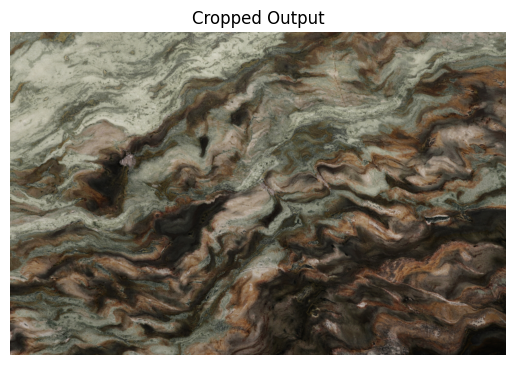

In [9]:
cropped = crop_image(img)

if cropped is not None:
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)

    plt.imshow(cropped_rgb)
    plt.title("Cropped Output")
    plt.axis("off")

    # Save next to original
    output_path = image_path.replace(".", "_cropped.")
    Image.fromarray(cropped_rgb).save(output_path)

    print(f"Saved to: {output_path}")
else:
    print("Cropping failed")

In [14]:
import logging
import time

import cv2
import numpy as np
from PIL import Image
from ultralytics import SAM

# Logging setup
log = logging.getLogger("crop_utils")

if not log.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("[%(name)s] %(levelname)s | %(message)s"))
    log.addHandler(handler)
    log.setLevel(logging.INFO)

# Load SAM model (runs once)
log.info("Loading SAM2 model…")
model = SAM("sam2_s.pt")
log.info("SAM2 model ready.")

[crop_utils] INFO | Loading SAM2 model…
[crop_utils] INFO | SAM2 model ready.


In [15]:
def crop_from_path(image_path: str) -> Image.Image | None:
    t0 = time.perf_counter()

    def _elapsed() -> str:
        return f"{time.perf_counter() - t0:.2f}s"

    try:
        img_bgr = cv2.imread(image_path)

        if img_bgr is None:
            log.warning(
                "CROP_SKIP | path=%s | reason=read_failed | elapsed=%s",
                image_path, _elapsed(),
            )
            return None

        h, w, _ = img_bgr.shape
        log.info(
            "LOADED_LOCAL | path=%s | size=%dx%d | elapsed=%s",
            image_path, w, h, _elapsed(),
        )

        center_y, center_x = h // 2, w // 2

        results = model.predict(
            img_bgr,
            points=[[center_x, center_y]],
            labels=[1],
            conf=0.4,
            verbose=False,
        )

        if results[0].masks is None:
            log.warning(
                "CROP_SKIP | path=%s | reason=no_masks_returned | elapsed=%s",
                image_path, _elapsed(),
            )
            return None

        masks = results[0].masks.data.cpu().numpy().astype(bool)

        candidate_indices = [
            i for i, m in enumerate(masks) if m[center_y, center_x]
        ]

        if not candidate_indices:
            log.warning(
                "CROP_SKIP | path=%s | reason=no_centre_covering_mask | elapsed=%s",
                image_path, _elapsed(),
            )
            return None

        target_idx = candidate_indices[
            np.argmax([np.sum(masks[i]) for i in candidate_indices])
        ]

        final_mask = masks[target_idx]
        y_coords, x_coords = np.where(final_mask)

        top, bottom = int(np.min(y_coords)), int(np.max(y_coords))
        left, right = int(np.min(x_coords)), int(np.max(x_coords))

        inset = 5
        cropped_bgr = img_bgr[
            max(0, top + inset): min(h, bottom - inset),
            max(0, left + inset): min(w, right - inset),
        ]

        if cropped_bgr.size == 0:
            log.warning(
                "CROP_SKIP | path=%s | reason=empty_crop | elapsed=%s",
                image_path, _elapsed(),
            )
            return None

        cropped_rgb = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(cropped_rgb)

        log.info(
            "CROP_SUCCESS | path=%s | crop=%dx%d | elapsed=%s",
            image_path, cropped_rgb.shape[1], cropped_rgb.shape[0], _elapsed(),
        )

        return pil_image

    except Exception as exc:
        log.error(
            "CROP_ERROR | path=%s | reason=%s | elapsed=%s",
            image_path, exc, _elapsed(),
        )
        return None

[crop_utils] INFO | LOADED_LOCAL | path=/home/Unthinkable/Downloads/stonex-development/image copy.png | size=1549x1043 | elapsed=0.06s


[crop_utils] INFO | CROP_SUCCESS | path=/home/Unthinkable/Downloads/stonex-development/image copy.png | crop=925x602 | elapsed=4.05s


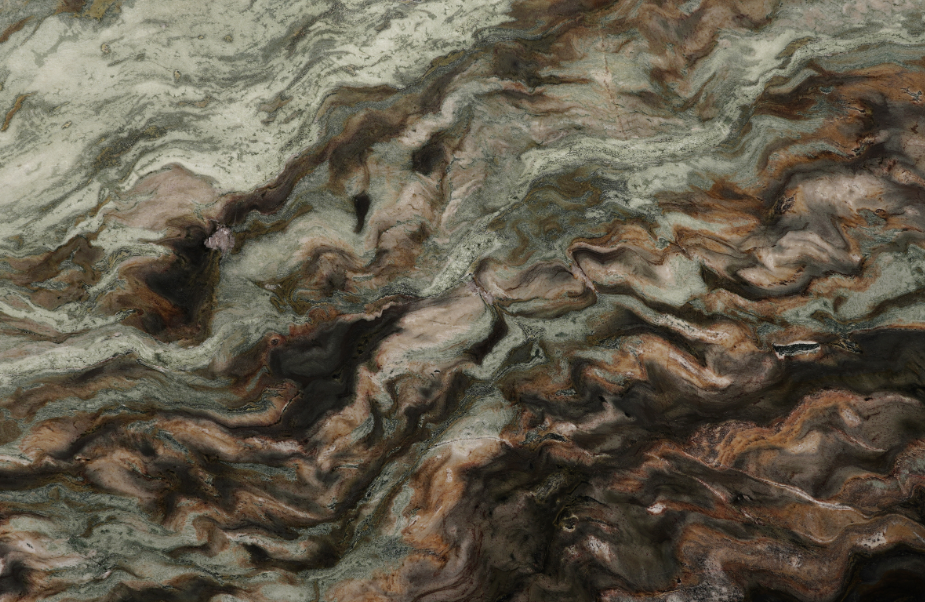

In [16]:
crop_from_path("/home/Unthinkable/Downloads/stonex-development/image copy.png")